In [3]:
# installing the dependencies
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# import the dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import QuantileTransformer

import joblib



**Upload Data**

In [6]:
df = pd.read_excel("Online Retail.xlsx")

| Variable Name | Role | Type | Description | Units | Missing Values |
|---|---|---|---|---|---|
| InvoiceNo | ID | Categorical | A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'C', it indicates a cancellation. | — | No |
| StockCode | ID | Categorical | A 5-digit integral number uniquely assigned to each distinct product. | — | No |
| Description | Feature | Categorical | Product name. | — | No |
| Quantity | Feature | Integer | The quantity of each product (item) per transaction. | — | No |
| InvoiceDate | Feature | Date | The day and time when each transaction was generated. | — | No |
| UnitPrice | Feature | Continuous | Product price per unit. | Sterling | No |
| CustomerID | Feature | Categorical | A 5-digit integral number uniquely assigned to each customer. | — | No |
| Country | Feature | Categorical | The name of the country where each customer resides. | — | No |

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.shape

(541909, 8)

**3. Exploratory Data Analysis (EDA)**

**1-Data Quality Check**

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [10]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [11]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [12]:
numerical_cols = ["Quantity", "UnitPrice"]
categorical_cols = [
    "InvoiceNo",
    "StockCode",
    "Description",
    "CustomerID",
    "Country"
]

In [13]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0


In [14]:
df.duplicated().sum()

np.int64(5268)

In [15]:
constant_features = [col for col in df.columns if df[col].nunique() == 1]

print("Constant Features:", constant_features)
print("Number of Constant Features:", len(constant_features))

threshold = 0.95

quasi_constant_features = []

for col in df.columns[:-1]:  # exclude the target column
    top_frequency = df[col].value_counts(normalize=True).iloc[0]
    if top_frequency >= threshold:
        quasi_constant_features.append(col)

print("Quasi-Constant Features:", quasi_constant_features)
print("Number of Quasi-Constant Features:", len(quasi_constant_features))

Constant Features: []
Number of Constant Features: 0
Quasi-Constant Features: []
Number of Quasi-Constant Features: 0


In [16]:
# Check for ID-like columns
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

InvoiceNo: 25900 unique values
StockCode: 4070 unique values
Description: 4223 unique values
Quantity: 722 unique values
InvoiceDate: 23260 unique values
UnitPrice: 1630 unique values
CustomerID: 4372 unique values
Country: 38 unique values


In [17]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
missing_values = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "missing_values_pre":((df.isnull().sum().values)/df.shape[0])*100
})

missing_values

,Column,Missing Values,missing_values_pre
0,InvoiceNo,0,0.000000
1,StockCode,0,0.000000
2,Description,1454,0.268311
3,Quantity,0,0.000000
4,InvoiceDate,0,0.000000
5,UnitPrice,0,0.000000
6,CustomerID,135080,24.926694
7,Country,0,0.000000


In [19]:
zero_percentage = (df.iloc[:, :-1] == 0).mean() * 100

zero_percentage.sort_values(ascending=False)

UnitPrice      0.4641
StockCode      0.0000
InvoiceNo      0.0000
Description    0.0000
Quantity       0.0000
InvoiceDate    0.0000
CustomerID     0.0000
dtype: float64

In [20]:
for col in df.columns:
    zero_count = (df[col] == 0).sum()
    
    if zero_count > 0:
        print(f"{col}: {zero_count} zero values")

UnitPrice: 2515 zero values


In [21]:
zero_price = df[df["UnitPrice"] == 0]

zero_price.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


# Data Quality & EDA — Identified Problems

| Problem | Evidence | Impact | Planned Treatment |
|---|---|---|---|
| **Mixed Data Types** | The dataset contains categorical/object, datetime, and numerical variables. | Different variable types require different preprocessing techniques. | Apply appropriate preprocessing based on each variable's role. Encode categorical variables only if they are used as model features. |
| **Missing Values** | Missing values were identified, particularly in `CustomerID` and `Description`. | Missing `CustomerID` prevents reliable customer-level analysis and RFM calculation. | Investigate and handle missing values based on their role in the analysis. |
| **Duplicate Records** | **5,260 duplicate rows** were identified. | Duplicates may cause transactions to be counted more than once and affect RFM calculations. | Investigate and remove exact duplicates if confirmed to be redundant. |
| **Zero Values in `UnitPrice`** | **2,515 transactions** have `UnitPrice = 0`. | These records result in `TotalAmount = 0` and may affect the Monetary component of RFM. | Investigate these transactions before deciding whether to remove them. |
| **Negative Values in `Quantity`** | `Quantity` ranges from **-80,995 to 80,995**. | Negative quantities may represent returns or cancelled transactions and should not automatically be treated as regular purchases. | Investigate cancelled/returned transactions and define an appropriate treatment. |
| **Negative Values in `UnitPrice`** | `UnitPrice` has a minimum value of **-11,062.06**. | Negative prices are unusual for normal purchases and may represent special records or data issues. | Investigate these records before deciding whether to remove them. |
| **Extreme / Long-Tailed Values** | `Quantity` ranges from **-80,995 to 80,995**, while `UnitPrice` ranges from **-11,062.06 to 38,970**. | Extreme values can strongly affect distributions, scaling, and distance-based clustering such as K-Means. | Investigate the source of extreme values first, then consider appropriate outlier treatment or transformation. |

## Distribution Observations

- `Quantity` contains extreme values on both the negative and positive sides.
- `UnitPrice` also contains extreme values, with a very large maximum compared with Q3.
- The large differences between the central values and extreme values suggest the presence of long tails and potential outliers.
- Skewness should be evaluated again **after cleaning invalid or special transactions**, since returns, cancellations, and zero/negative values can distort the original distributions.

## Important Note

> The presence of mixed data types does not mean that all categorical or datetime columns should be encoded. Each variable should be handled according to its role in the analysis and modeling process.

### Variable Roles for the RFM Analysis

- `CustomerID` → Customer identifier / grouping key
- `InvoiceNo` → Transaction identifier / used to calculate Frequency
- `StockCode` → Product identifier
- `Description` → Categorical/text variable
- `Country` → Categorical variable
- `InvoiceDate` → Datetime variable / used to calculate Recency
- `Quantity` → Numerical variable
- `UnitPrice` → Numerical variable

2-Visualization EDA


1- Numerical


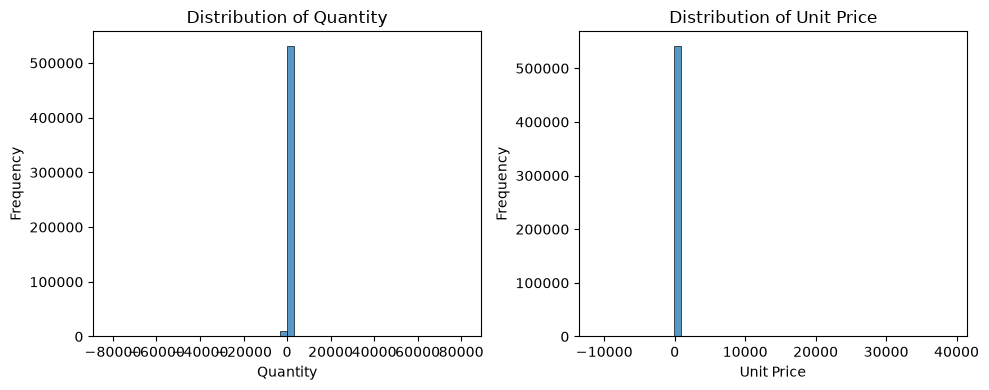

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes = axes.flatten()

# Quantity - Histogram
sns.histplot(df["Quantity"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of Quantity")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")



# UnitPrice - Histogram
sns.histplot(df["UnitPrice"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of Unit Price")
axes[1].set_xlabel("Unit Price")
axes[1].set_ylabel("Frequency")



plt.tight_layout()
plt.show()

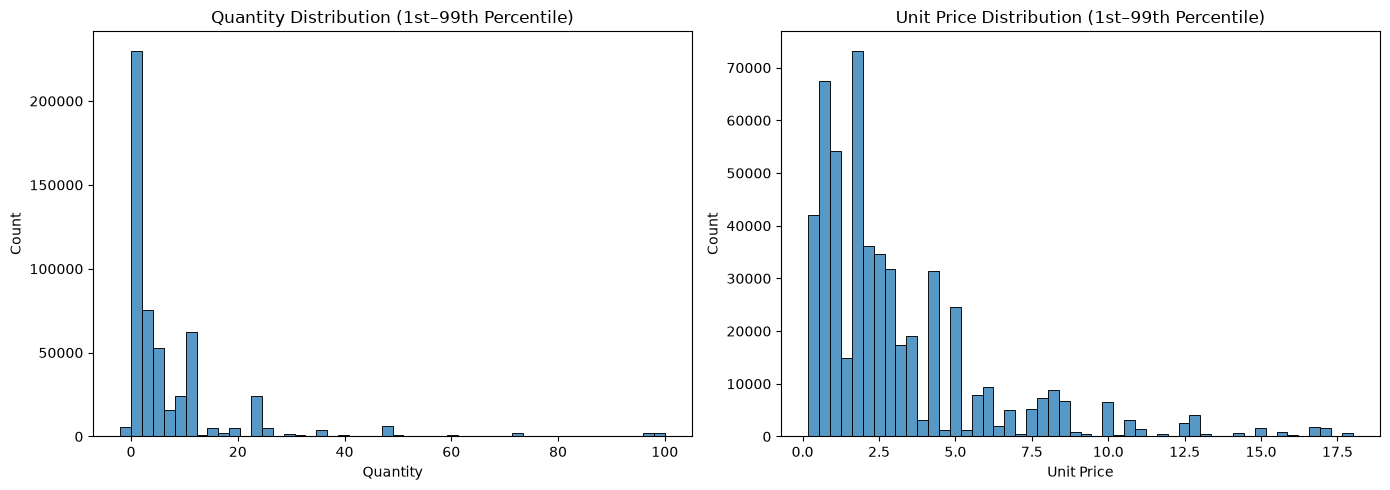

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()

# Quantity
q_low = df["Quantity"].quantile(0.01)
q_high = df["Quantity"].quantile(0.99)

quantity_filtered = df[
    df["Quantity"].between(q_low, q_high)
]

sns.histplot(
    quantity_filtered["Quantity"],
    bins=50,
    ax=axes[0]
)

axes[0].set_title("Quantity Distribution (1st–99th Percentile)")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Count")


# UnitPrice
p_low = df["UnitPrice"].quantile(0.01)
p_high = df["UnitPrice"].quantile(0.99)

price_filtered = df[
    df["UnitPrice"].between(p_low, p_high)
]

sns.histplot(
    price_filtered["UnitPrice"],
    bins=50,
    ax=axes[1]
)

axes[1].set_title("Unit Price Distribution (1st–99th Percentile)")
axes[1].set_xlabel("Unit Price")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

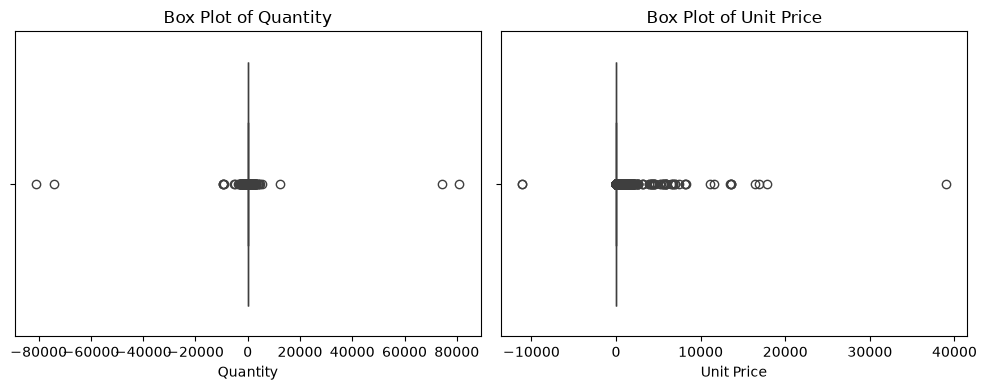

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

# Quantity - Box Plot
sns.boxplot(x=df["Quantity"], ax=axes[0])
axes[0].set_title("Box Plot of Quantity")
axes[0].set_xlabel("Quantity")


# UnitPrice - Box Plot
sns.boxplot(x=df["UnitPrice"], ax=axes[1])
axes[1].set_title("Box Plot of Unit Price")
axes[1].set_xlabel("Unit Price")


plt.tight_layout()
plt.show()

### 📊 Handling Extreme Values for Visualization

For the histogram, we temporarily focused on the **1st–99th percentile** range.

- Approximately **98% of the data** is included.
- Approximately **2% of the data** (the extreme values) is excluded from the visualization.
- This does **not** mean that we deleted or removed these values from the dataset.
- The purpose is only to make the distribution easier to visualize without extreme values dominating the plot.

> **Note:** A small number of outliers does not necessarily mean they should be removed. We need to determine whether they represent errors or legitimate transactions before applying any preprocessing.

In [25]:
negative_price = df[df["UnitPrice"] < 0]

negative_price[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
299983,A563186,B,Adjust bad debt,1,-11062.06
299984,A563187,B,Adjust bad debt,1,-11062.06


### Box Plot Visualization

Box plots were created using the **original dataset without removing or filtering any values**.

- The box represents the **IQR** (middle 50%).
- The line inside represents the **median**.
- Whiskers show the typical range.
- Points beyond the whiskers are potential **outliers**.

> **Note:** No preprocessing was performed. The visualization was used to identify unusual values.

### Outlier Investigation

Negative `UnitPrice` values were investigated and found to be related to **"Adjust bad debt"** transactions.
Most `UnitPrice`,`Quantity` values are concentrated within a relatively narrow range, while only a small number of observations appear as extreme outliers.
These outliers are located far from the main distribution and may require further investigation based on their business meaning rather than being removed automatically.

These are **financial adjustments, not actual product sales**, so they will be excluded later from the **RFM/customer purchase analysis** to avoid distorting monetary calculations.

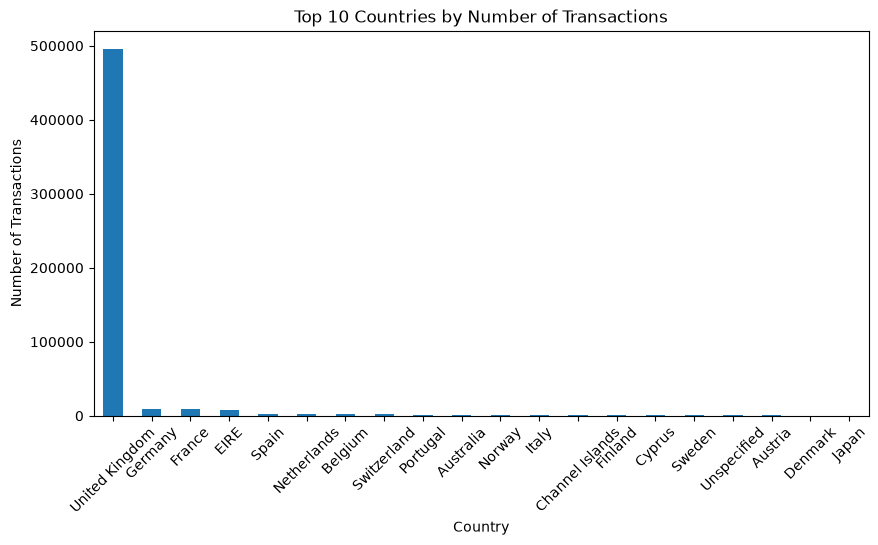

In [26]:
country_counts = df["Country"].value_counts().head(20)

country_counts.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

> The United k (Uk) has the highest number of transactions in the dataset.

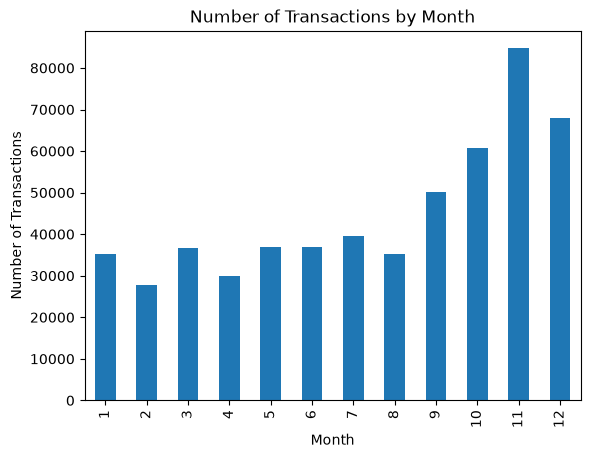

In [27]:
df.groupby(df["InvoiceDate"].dt.month).size().plot(kind="bar")
plt.title("Number of Transactions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

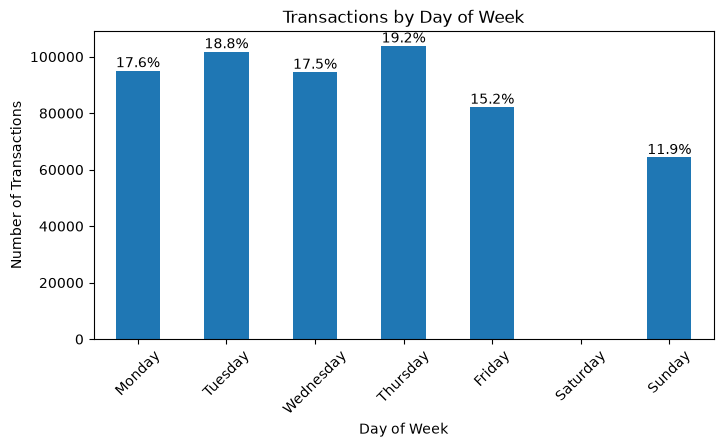

In [28]:
days = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_counts = (
    df["InvoiceDate"]
    .dt.day_name()
    .value_counts()
    .reindex(days)
)

ax = day_counts.plot(kind="bar", figsize=(8,4))

total = day_counts.sum()

for i, value in enumerate(day_counts):
    percentage = (value / total) * 100
    ax.text(
        i,
        value,
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Transactions by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

In [29]:
df["InvoiceDate"].dt.day_name().value_counts()

InvoiceDate
Thursday     103857
Tuesday      101808
Monday        95111
Wednesday     94565
Friday        82193
Sunday        64375
Name: count, dtype: int64

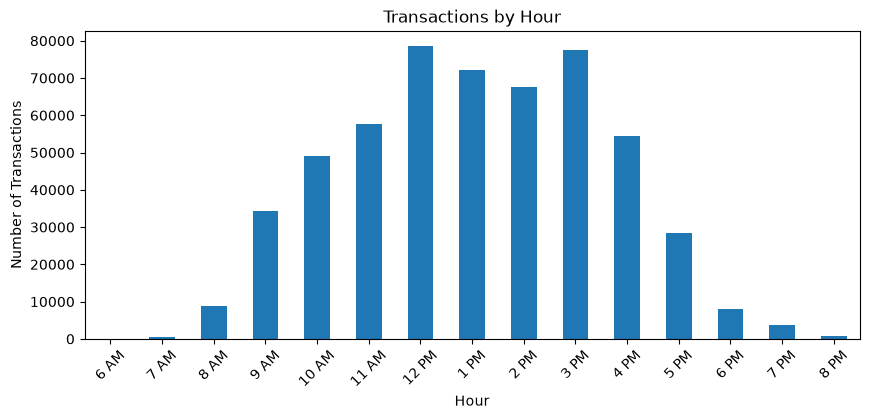

In [30]:
hour_counts = df["InvoiceDate"].dt.hour.value_counts().sort_index()

ax = hour_counts.plot(kind="bar", figsize=(10, 4))

ax.set_xticklabels([
    pd.to_datetime(str(h), format="%H").strftime("%I %p").lstrip("0")
    for h in hour_counts.index
])

plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

In [31]:
df["InvoiceDate"].dt.hour.value_counts()

InvoiceDate
12    78709
15    77519
13    72259
14    67471
11    57674
16    54516
10    49037
9     34332
17    28509
8      8909
18     7974
19     3705
20      871
7       383
6        41
Name: count, dtype: int64

### 📅 InvoiceDate Insights

- **Day of Week:** Transactions are distributed across most days with relatively small differences. **Thursday** has the highest activity, while **Saturday has no recorded transactions**.
- **Month:** Transaction activity varies across months, with **November** having the highest number of transactions.
- **Hour:** Most transactions occur during the **daytime, mainly between 8 AM and 5 PM**, with the highest activity around midday.


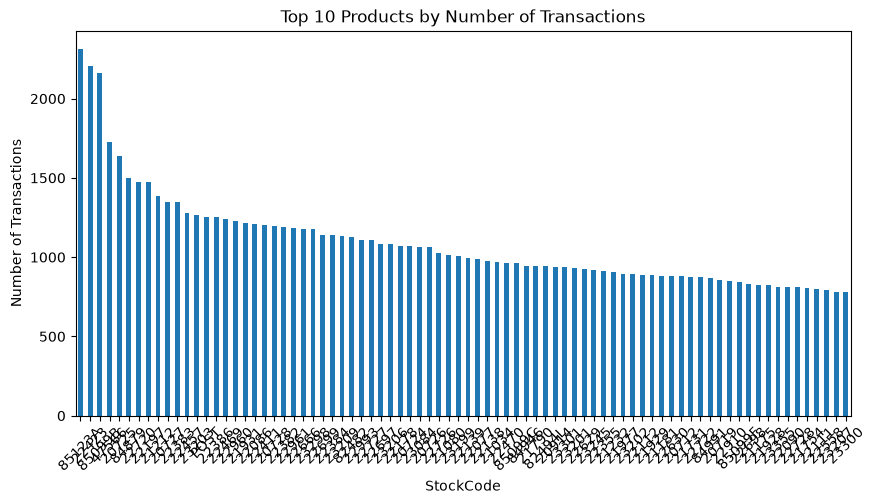

In [32]:
top_products = df["StockCode"].value_counts().head(80)

top_products.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Products by Number of Transactions")
plt.xlabel("StockCode")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

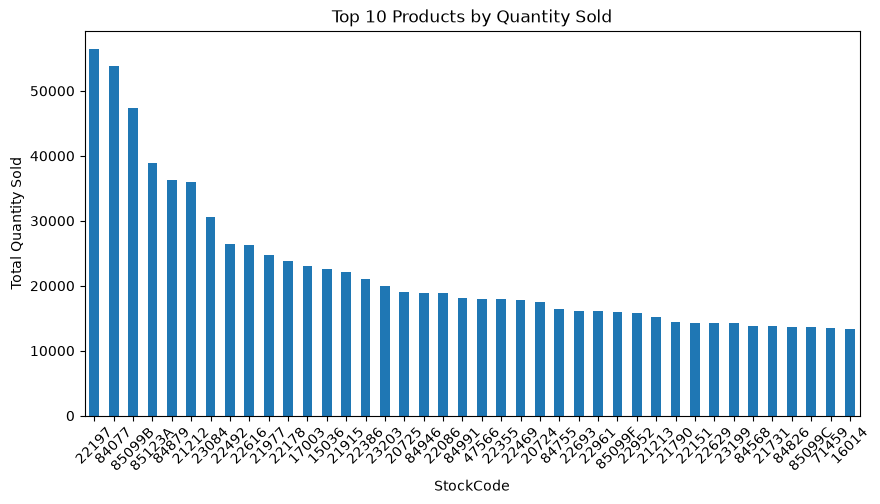

In [33]:
top_quantity = (
    df.groupby("StockCode")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(40)
)

top_quantity.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("StockCode")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()

In [34]:
top_quantity = (
    df.groupby("StockCode")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [35]:
top_quantity

StockCode
22197     56450
84077     53847
85099B    47363
85123A    38830
84879     36221
21212     36039
23084     30646
22492     26437
22616     26315
21977     24753
Name: Quantity, dtype: int64

**Start Data Cleaning / Preprocessing**

In [36]:
df.duplicated().sum()

np.int64(5268)

In [37]:
df.drop_duplicates(inplace=True)

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [40]:
negative_qty = df[df["Quantity"] < 0]

len(negative_qty), len(negative_qty) / len(df) * 100

(10587, 1.9728272718633126)

In [41]:
negative_qty[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
141,C536379,D,Discount,-1,27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65
939,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25


In [42]:
negative_qty = df[df["Quantity"] < 0].copy()

negative_qty["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True     9251
False    1336
Name: count, dtype: int64

In [43]:
negative_not_cancelled = negative_qty[
    ~negative_qty["InvoiceNo"].astype(str).str.startswith("C")
]

negative_not_cancelled[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
2406,536589,21777,NaN,-10,0.0
4347,536764,84952C,NaN,-38,0.0
7188,536996,22712,NaN,-20,0.0
7189,536997,22028,NaN,-20,0.0
7190,536998,85067,NaN,-6,0.0
7192,537000,21414,NaN,-22,0.0
7193,537001,21653,NaN,-6,0.0
7195,537003,85126,NaN,-2,0.0
7196,537004,21814,NaN,-30,0.0
7197,537005,21692,NaN,-70,0.0


In [44]:
negative_not_cancelled = negative_qty[
    ~negative_qty["InvoiceNo"].astype(str).str.startswith("C")
]

print("Count:", len(negative_not_cancelled))

print(
    "Negative Quantity + Zero Price:",
    ((negative_not_cancelled["UnitPrice"] == 0)).sum()
)

print(
    "Missing Description:",
    negative_not_cancelled["Description"].isna().sum()
)

Count: 1336
Negative Quantity + Zero Price: 1336
Missing Description: 862


In [45]:
df["CustomerID"].isna().mean() * 100

np.float64(25.163377378918124)

In [46]:
rfm_df = df.dropna(subset=["CustomerID"]).copy()
rfm_df = rfm_df[
    ~rfm_df["InvoiceNo"].astype(str).str.startswith("C")
].copy()

In [47]:
rfm_df.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### 🧹 Handling Missing Values for RFM

Approximately **25.16% of the transactions have missing `CustomerID` values**. Since `CustomerID` is required to perform customer-level RFM analysis, these transactions cannot be reliably assigned to a specific customer.

Therefore, transactions with missing `CustomerID` were excluded **only from the RFM dataset**, while the original dataset was preserved.

> **Note:** Removing the rows with missing `CustomerID` also removed the corresponding missing `Description` values in those rows. Therefore, no additional row removal based on missing `Description` is required.

In [48]:
negative_qty = rfm_df[rfm_df["Quantity"] < 0].copy()

negative_qty["InvoiceNo"].astype(str).str.startswith("C").value_counts()

Series([], Name: count, dtype: int64)

In [49]:
negative_not_cancelled = negative_qty[
    ~negative_qty["InvoiceNo"].astype(str).str.startswith("C")
]

print("Count:", len(negative_not_cancelled))

print(
    "Negative Quantity + Zero Price:",
    ((negative_not_cancelled["UnitPrice"] == 0)).sum()
)

print(
    "Missing Description:",
    negative_not_cancelled["Description"].isna().sum()
)

Count: 0
Negative Quantity + Zero Price: 0
Missing Description: 0


In [50]:
rfm_df["CustomerID"].isna().sum()

np.int64(0)

## Why Do We Use RFM?

The original dataset is **transaction-level**, where each row represents a transaction or purchased product.

For **Customer Segmentation**, we need **customer-level features**, where each row represents one customer.

RFM transforms transaction data into meaningful customer behavior features:

- **Recency:** How recently the customer purchased.
- **Frequency:** How often the customer purchased.
- **Monetary:** How much the customer spent.

Therefore, RFM provides a simple and meaningful representation of **customer purchasing behavior** that can be used as input features for the clustering model.

**Recency**

In [51]:
rfm_df["TotalPrice"] = rfm_df["Quantity"] * rfm_df["UnitPrice"]

In [52]:
rfm_df["InvoiceDate"] = pd.to_datetime(rfm_df["InvoiceDate"])

In [53]:
reference_date = rfm_df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [54]:
reference_date

Timestamp('2011-12-10 12:50:00')

In [55]:
rfm_df["InvoiceDate"].dtype

dtype('<M8[us]')

In [56]:
last_purchase = rfm_df.groupby("CustomerID")["InvoiceDate"].max()


In [57]:
last_purchase.head(10)

CustomerID
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
12352.0   2011-11-03 14:37:00
12353.0   2011-05-19 17:47:00
12354.0   2011-04-21 13:11:00
12355.0   2011-05-09 13:49:00
12356.0   2011-11-17 08:40:00
Name: InvoiceDate, dtype: datetime64[us]

In [58]:
recency = (reference_date - last_purchase).dt.days

In [59]:
recency.head(10)

CustomerID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
12352.0     36
12353.0    204
12354.0    232
12355.0    214
12356.0     23
Name: InvoiceDate, dtype: int64

**Frequency**

In [60]:
frequency = rfm_df.groupby("CustomerID")["InvoiceNo"].nunique()

In [61]:
frequency.head(10)

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
12352.0    8
12353.0    1
12354.0    1
12355.0    1
12356.0    3
Name: InvoiceNo, dtype: int64

In [62]:
rfm_df["TotalPrice"] = rfm_df["Quantity"] * rfm_df["UnitPrice"]

In [63]:
rfm_df[["Quantity", "UnitPrice", "TotalPrice"]].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [64]:
monetary = rfm_df.groupby("CustomerID")["TotalPrice"].sum()

In [65]:
monetary.head(10)

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
12352.0     2506.04
12353.0       89.00
12354.0     1079.40
12355.0      459.40
12356.0     2811.43
Name: TotalPrice, dtype: float64

In [66]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

In [67]:
rfm.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


## RFM Analysis

| Metric | Meaning |
|---|---|
| **Recency** | How many days since the customer's last purchase. **Lower is better.** |
| **Frequency** | How many unique purchases/invoices the customer made. **Higher is better.** |
| **Monetary** | Total amount spent by the customer. **Higher is better.** |

**TotalPrice = Quantity × UnitPrice**

In [68]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4339.0,92.518322,100.009747,1.0,18.000,51.00,142.000,374.00
Frequency,4339.0,4.271952,7.705493,1.0,1.000,2.00,5.000,210.00
Monetary,4339.0,2048.215924,8984.248352,0.0,306.455,668.56,1660.315,280206.02


In [69]:
rfm_df[rfm_df["Quantity"] < 0][
    ["InvoiceNo", "CustomerID", "Quantity", "UnitPrice"]
].head(10)

,InvoiceNo,CustomerID,Quantity,UnitPrice


In [70]:
(rfm_df["Quantity"] < 0).sum()

np.int64(0)

In [71]:
rfm_df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(0)

array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

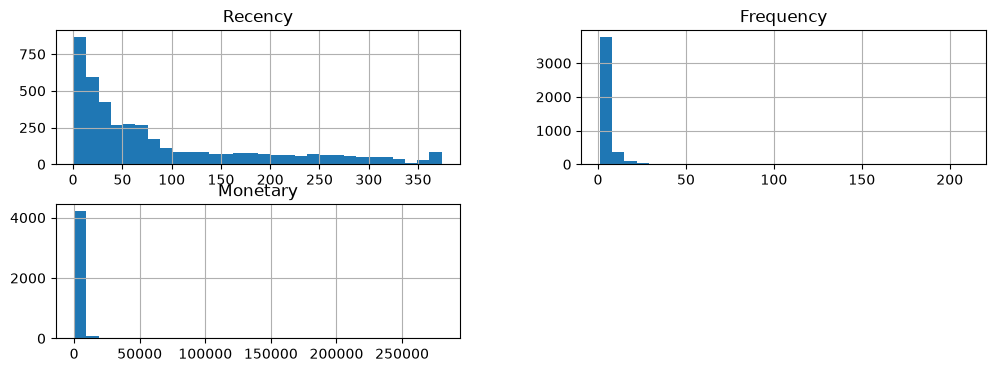

In [72]:
rfm.hist(bins=30, figsize=(12, 4))

In [73]:
rfm.skew()

Recency       1.246357
Frequency    12.100028
Monetary     19.341403
dtype: float64

## Preprocessing & Clustering Pipeline

```text
RFM
 ↓
Log Transformation
 ↓
StandardScaler
 ↓
Clustering Models
 ├── K-Means
 ├── Hierarchical Clustering
 └── DBSCAN

In [74]:
# preprocessor = Pipeline([
#     ("log_transform", FunctionTransformer(np.log1p)),
#     ("scaler", StandardScaler())
# ])
preprocessor = Pipeline([
    ("quantile", QuantileTransformer(output_distribution='normal', random_state=42))
])

In [75]:
rfm_scaled = preprocessor.fit_transform(rfm)

In [76]:
rfm_processed = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_processed.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.786156,-5.199338,2.867723
12347.0,-1.865852,1.059682,1.425651
12348.0,0.304482,0.520661,0.734862
12349.0,-0.622621,-5.199338,0.717878
12350.0,1.615945,-5.199338,-0.564188


array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

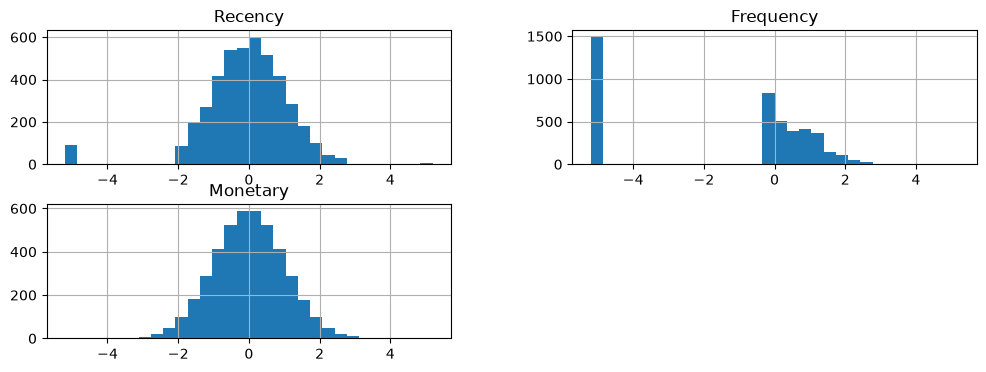

In [77]:
rfm_processed.hist(bins=30, figsize=(12, 4))

In [78]:

rfm_processed.skew()

Recency     -1.265103
Frequency   -0.527389
Monetary     0.000383
dtype: float64

In [79]:
rfm_processed.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4339.0,-0.056499,1.215752,-5.199338,-0.665852,0.002509,0.673702,5.199338
Frequency,4339.0,-1.421212,2.792174,-5.199338,-5.199338,-0.148584,0.743040,5.199338
Monetary,4339.0,0.000011,1.004218,-5.199338,-0.673943,-0.000577,0.675784,5.199338


 **5. Elbow Method**

(Find best k value)

In [80]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_processed)
    inertia.append(kmeans.inertia_)

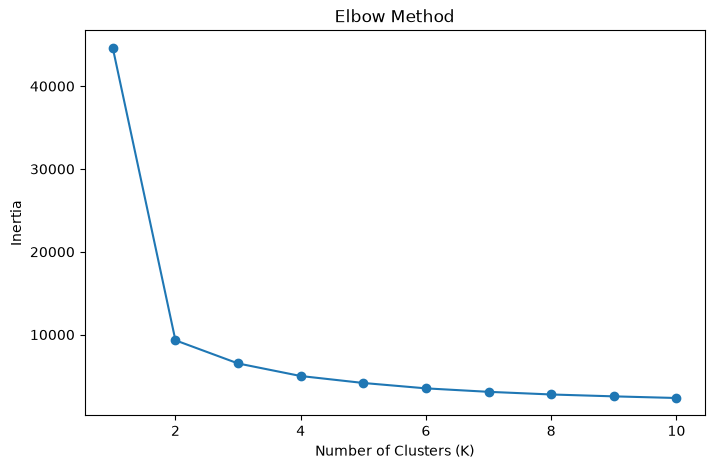

In [81]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [82]:
inertia

[44606.53695906414,
 9314.681473476057,
 6520.434442317998,
 5002.951917662416,
 4163.1380139675075,
 3512.974381128597,
 3093.8638677437066,
 2774.6517696137853,
 2547.558884589769,
 2349.4225899498815]

In [83]:
# best k is 3
best_k=3
k_means=KMeans(n_clusters=best_k,n_init=10,random_state=42)

In [84]:
k_means.fit(rfm_processed)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 3)","[[ 0.

In [85]:
k_pred=k_means.predict(rfm_processed)

In [86]:
k_pred

array([0, 2, 1, ..., 1, 2, 1], shape=(4339,), dtype=int32)

In [87]:
rfm_processed['k_means clustring']=k_pred

In [88]:
rfm_processed.head(10)

,Recency,Frequency,Monetary,k_means clustring
CustomerID,,,,
12346.0,1.786156,-5.199338,2.867723,0
12347.0,-1.865852,1.059682,1.425651,2
12348.0,0.304482,0.520661,0.734862,1
12349.0,-0.622621,-5.199338,0.717878,0
12350.0,1.615945,-5.199338,-0.564188,0
12352.0,-0.202098,1.189522,0.990271,2
12353.0,0.961429,-5.199338,-1.927073,0
12354.0,1.086456,-5.199338,0.364126,0
12355.0,1.012474,-5.199338,-0.295906,0


In [89]:
k_score = silhouette_score(
    rfm_processed[["Recency", "Frequency", "Monetary"]],
    rfm_processed["k_means clustring"]
)

print(k_score)

0.5156658856655797


## Impact of QuantileTransformer

The initial clustering model achieved a Silhouette Score of approximately **0.30** using the previous scaling and transformation approach.

After replacing the preprocessing step with **QuantileTransformer**, the Silhouette Score increased to **0.5157**.

This improvement indicates that the transformed RFM features produced a more suitable representation for K-Means clustering and resulted in better-defined customer segments.

| Preprocessing | Silhouette Score |
|---|---:|
| Previous Scaling & Transformation | ~0.30 |
| **QuantileTransformer** | **0.5157** |

Therefore, QuantileTransformer was selected as the final preprocessing method for the clustering pipeline.

In [90]:
feature_pairs = [
    ("Recency", "Frequency"),
    ("Recency", "Monetary"),
    ("Frequency", "Monetary")
]

In [91]:
rfm_plot = rfm_processed.copy()
rfm_plot["KMeans_Cluster"] = k_pred

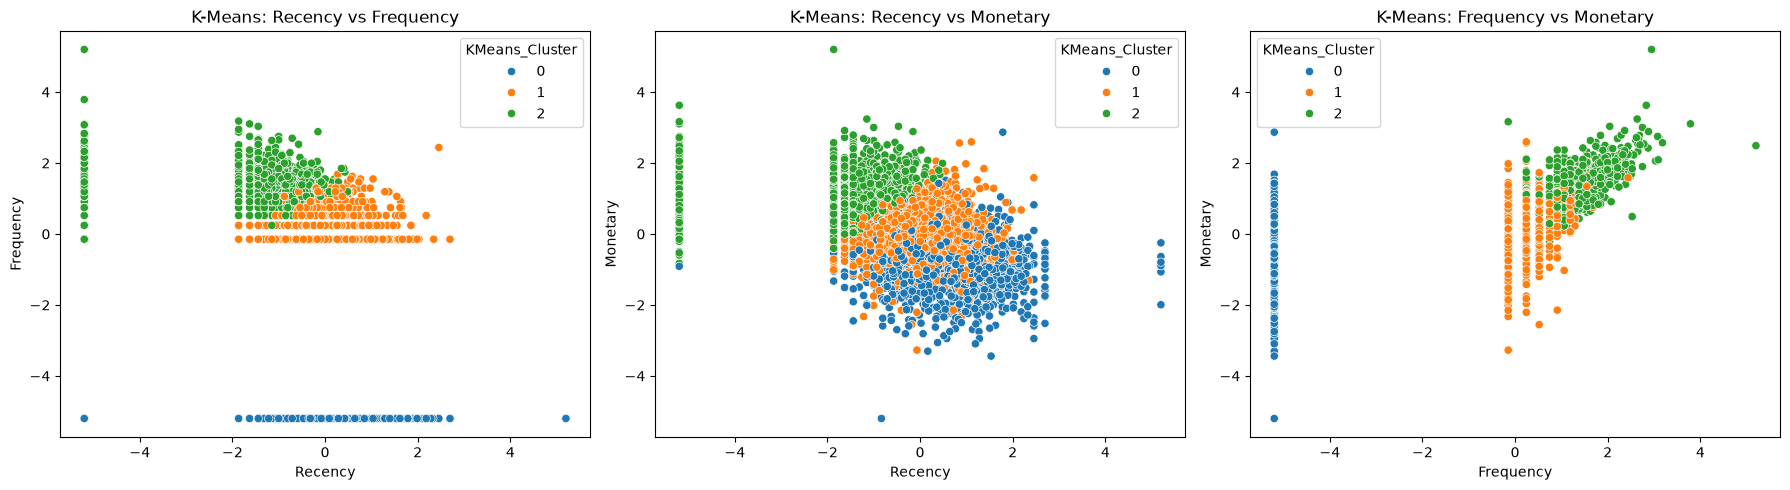

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for ax, (x, y) in zip(axes, feature_pairs):

    sns.scatterplot(
        data=rfm_plot,
        x=x,
        y=y,
        hue="KMeans_Cluster",
        palette="tab10",
        ax=ax
    )

    ax.set_title(f"K-Means: {x} vs {y}")

plt.tight_layout()
plt.show()

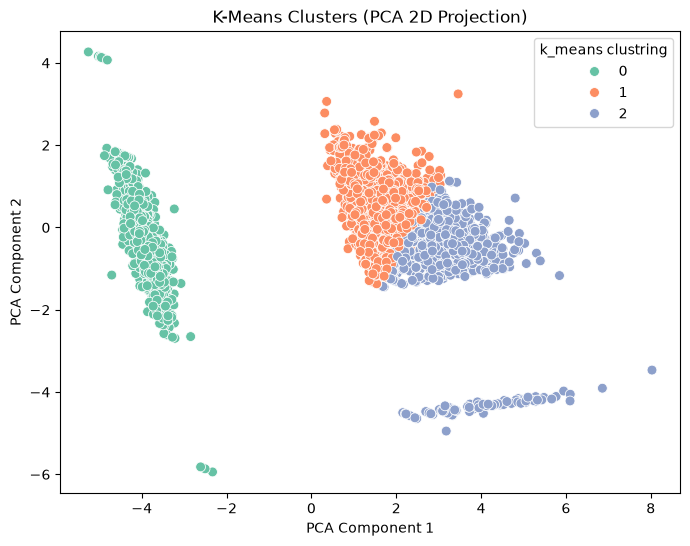

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. تقليل الـ 3 أبعاد لبُعدين
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_processed[["Recency", "Frequency", "Monetary"]])

# 2. الرسم
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=rfm_pca[:, 0],
    y=rfm_pca[:, 1],
    hue=rfm_processed["k_means clustring"],
    palette="Set2",
    s=50,
)
plt.title("K-Means Clusters (PCA 2D Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [94]:
cluster_names = {
    0: "At-Risk / Hibernating",     
    1: "Potential Loyalists",       
    2: "Champions / VIP"             
}

In [95]:
def predict_customer_segment(recency, frequency, monetary):
    new_customer = pd.DataFrame([{
        'Recency': recency,
        'Frequency': frequency,
        'Monetary': monetary
    }])
    
    scaled_array = preprocessor.transform(new_customer)
    
    scaled_df = pd.DataFrame(
        scaled_array, 
        columns=['Recency', 'Frequency', 'Monetary']
    )
    
    cluster_id = k_means.predict(scaled_df)[0]
    segment_name = cluster_names.get(cluster_id, "Unknown Segment")
    
    return cluster_id, segment_name

In [96]:
cluster_id, segment = predict_customer_segment(recency=2000, frequency=1, monetary=15000)
print(f"Cluster ID: {cluster_id} | Segment Name: {segment}")

Cluster ID: 0 | Segment Name: At-Risk / Hibernating


In [97]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# استخدام البيانات المصعرة والـ Cluster Labels
X = rfm_processed[["Recency", "Frequency", "Monetary"]]
labels = rfm_processed["k_means clustring"]

# 1. Silhouette Score
sil_score = silhouette_score(X, labels)

# 2. Davies-Bouldin Index (Lower is better)
db_score = davies_bouldin_score(X, labels)

# 3. Calinski-Harabasz Index (Higher is better)
ch_score = calinski_harabasz_score(X, labels)

print(f"Silhouette Score (Target: > 0.5): {sil_score:.4f}")
print(f"Davies-Bouldin Index (Target: Close to 0): {db_score:.4f}")
print(f"Calinski-Harabasz Index (Target: Higher is better): {ch_score:.2f}")

Silhouette Score (Target: > 0.5): 0.5157
Davies-Bouldin Index (Target: Close to 0): 0.8037
Calinski-Harabasz Index (Target: Higher is better): 12663.41


In [98]:
test_customers = [
    {"name": "VIP / Champion", "recency": 2, "frequency": 45, "monetary": 12000},
    {"name": "Loyal / Regular", "recency": 15, "frequency": 12, "monetary": 2500},
    {"name": "At-Risk / Low", "recency": 220, "frequency": 1, "monetary": 40},
    {"name": "Edge Case (High Spender but Inactive)", "recency": 300, "frequency": 20, "monetary": 15000}
]

for customer in test_customers:
    c_id, seg = predict_customer_segment(customer["recency"], customer["frequency"], customer["monetary"])
    print(f"Customer Type: {customer['name']}")
    print(f"Inputs -> R: {customer['recency']}, F: {customer['frequency']}, M: {customer['monetary']}")
    print(f"Predicted Cluster: {c_id} ({seg})")
    print("-" * 50)

Customer Type: VIP / Champion
Inputs -> R: 2, F: 45, M: 12000
Predicted Cluster: 2 (Champions / VIP)
--------------------------------------------------
Customer Type: Loyal / Regular
Inputs -> R: 15, F: 12, M: 2500
Predicted Cluster: 2 (Champions / VIP)
--------------------------------------------------
Customer Type: At-Risk / Low
Inputs -> R: 220, F: 1, M: 40
Predicted Cluster: 0 (At-Risk / Hibernating)
--------------------------------------------------
Customer Type: Edge Case (High Spender but Inactive)
Inputs -> R: 300, F: 20, M: 15000
Predicted Cluster: 1 (Potential Loyalists)
--------------------------------------------------


In [99]:
from sklearn.cluster import AgglomerativeClustering
agg_model = AgglomerativeClustering(n_clusters=3)
agg_labels = agg_model.fit_predict(rfm_processed[["Recency", "Frequency", "Monetary"]])

agg_sil = silhouette_score(rfm_processed[["Recency", "Frequency", "Monetary"]], agg_labels)
print(f"Hierarchical Silhouette Score: {agg_sil:.4f}")

Hierarchical Silhouette Score: 0.5020


In [100]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels = dbscan.fit_predict(rfm_processed[["Recency", "Frequency", "Monetary"]])

print("Clusters found:", set(db_labels))

Clusters found: {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}


## Why K-Means Was Selected

K-Means was selected as the final clustering algorithm for this project based on both **clustering performance** and **production requirements**.

The main reasons for choosing K-Means are:

- **Highest Silhouette Score:** K-Means achieved a Silhouette Score of **0.5157**, slightly outperforming Agglomerative Clustering (**0.5020**), indicating better cluster separation.
- **Efficient:** K-Means is computationally efficient and scales well as the number of customers increases.
- **Easy to Interpret:** The resulting clusters can be easily analyzed and translated into meaningful customer segments based on their **Recency, Frequency, and Monetary** characteristics.
- **Suitable for Real-Time Prediction:** Unlike Agglomerative Clustering, K-Means provides a built-in `predict()` method, allowing new customers to be assigned to an existing cluster without retraining the model.
- **Suitable for Deployment:** Its relatively low computational cost makes K-Means a practical choice for deployment through **FastAPI** and integration with a **React dashboard**.
- **Consistent Customer Assignment:** K-Means assigns every customer to one of the predefined clusters, which is important for our business segmentation use case.

### Final Decision

Based on the combination of **Silhouette Score, efficiency, interpretability, scalability, and real-time prediction capability**, **K-Means with K=3 and QuantileTransformer preprocessing** was selected as the final production model.

In [ ]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("kmeans", k_means)
])

joblib.dump(
    final_pipeline,
    "CUSTOMER_SEGMENTAION_MODEL.pkl"
)

['CUSTOMER_SEGMENTAION_MODEL.pkl']